In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import random
warnings.filterwarnings('ignore')
random.seed(200)

# The proposed target metric is ROC-AUC
ROC-AUC masures how well the model ranks positive and negative observations across thresholds. There are some obvious advantages and drawbacks.

Advantages:

threshold independent;
considers ranking over the full score range;
relatively insensitive to the absolute class proportions in its formulation;
exactly matches the competition objective.

But:

it can provide an optimistic-looking picture when the positive class is rare;
it gives substantial attention to ranking among negative observations;
it doesn't directly tell us how many predicted positives are actually positive;
it doesn't evaluate probability calibration;
it doesn't encode the operational cost of false positives vs false negatives.

PR-AUC on the other hand
Focuses on: Precision = TP/(TP+FP)
and
Recall = TP/(TP+FN)
across thresholds.

Therefore it directly examines the model's ability to identify the minority positive class while controlling false positives. That's our justification for considering PR-AUC as a secondary metric.
But we would not claim that PR-AUC is universally superior.

ROC-AUC is retained as the official competition metric, while PR-AUC is proposed as an alternative evaluation metric because it provides a complementary view that is particularly informative for the imbalanced default class.

In [2]:
DATA_PATH = Path('/kaggle/input/competitions/home-credit-default-risk')
df_train = pd.read_csv(DATA_PATH / 'application_train.csv')
df_test = pd.read_csv(DATA_PATH / 'application_test.csv')

print(f'Train shape: {df_train.shape}')
print(f'Test shape: {df_test.shape}')
print(f'Train columns: {df_train.columns.tolist()[:10]}...')

Train shape: (307511, 122)
Test shape: (48744, 121)
Train columns: ['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']...


In [3]:
print('Training data shape: ', df_train.shape)
df_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# DATASET OVERVIEW

There are some worries about the dataset itself which we want to invesigate, those are first that comes to mind, but not end here:

Target-Oriented	- Age, income, credit burden, missingness, default rates

Data Quality - Outliers (IQR), skewness, impossible values, constants

Feature Relationships - Correlations, interactions, heatmaps

Multi-Table	- Bureau history, approved apps, delinquency (if available)

Train/Test - Distribution/missingness diffs, categorical shifts

In [4]:
print('BASIC STATISTICS')
print(f"Rows: {len(df_train)} | Columns: {df_train.shape[1]}")
print(f"Data types:\n{df_train.dtypes.value_counts()}")
print(f"Target (default rate): {df_train['TARGET'].mean():.3%}")

BASIC STATISTICS
Rows: 307511 | Columns: 122
Data types:
float64    65
int64      41
object     16
Name: count, dtype: int64
Target (default rate): 8.073%


In [5]:
missing_stats = pd.DataFrame({
    'missing_count': df_train.isna().sum(),
    'missing_%': (df_train.isna().mean() * 100).round(2)
})
missing_stats = missing_stats[missing_stats['missing_count'] > 0].sort_values('missing_%', ascending=False)
print(f'Columns with missing values: {len(missing_stats)} / {len(df_train.columns)}')
print(missing_stats.head(10))

Columns with missing values: 67 / 122
                          missing_count  missing_%
COMMONAREA_MEDI                  214865      69.87
COMMONAREA_MODE                  214865      69.87
COMMONAREA_AVG                   214865      69.87
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35


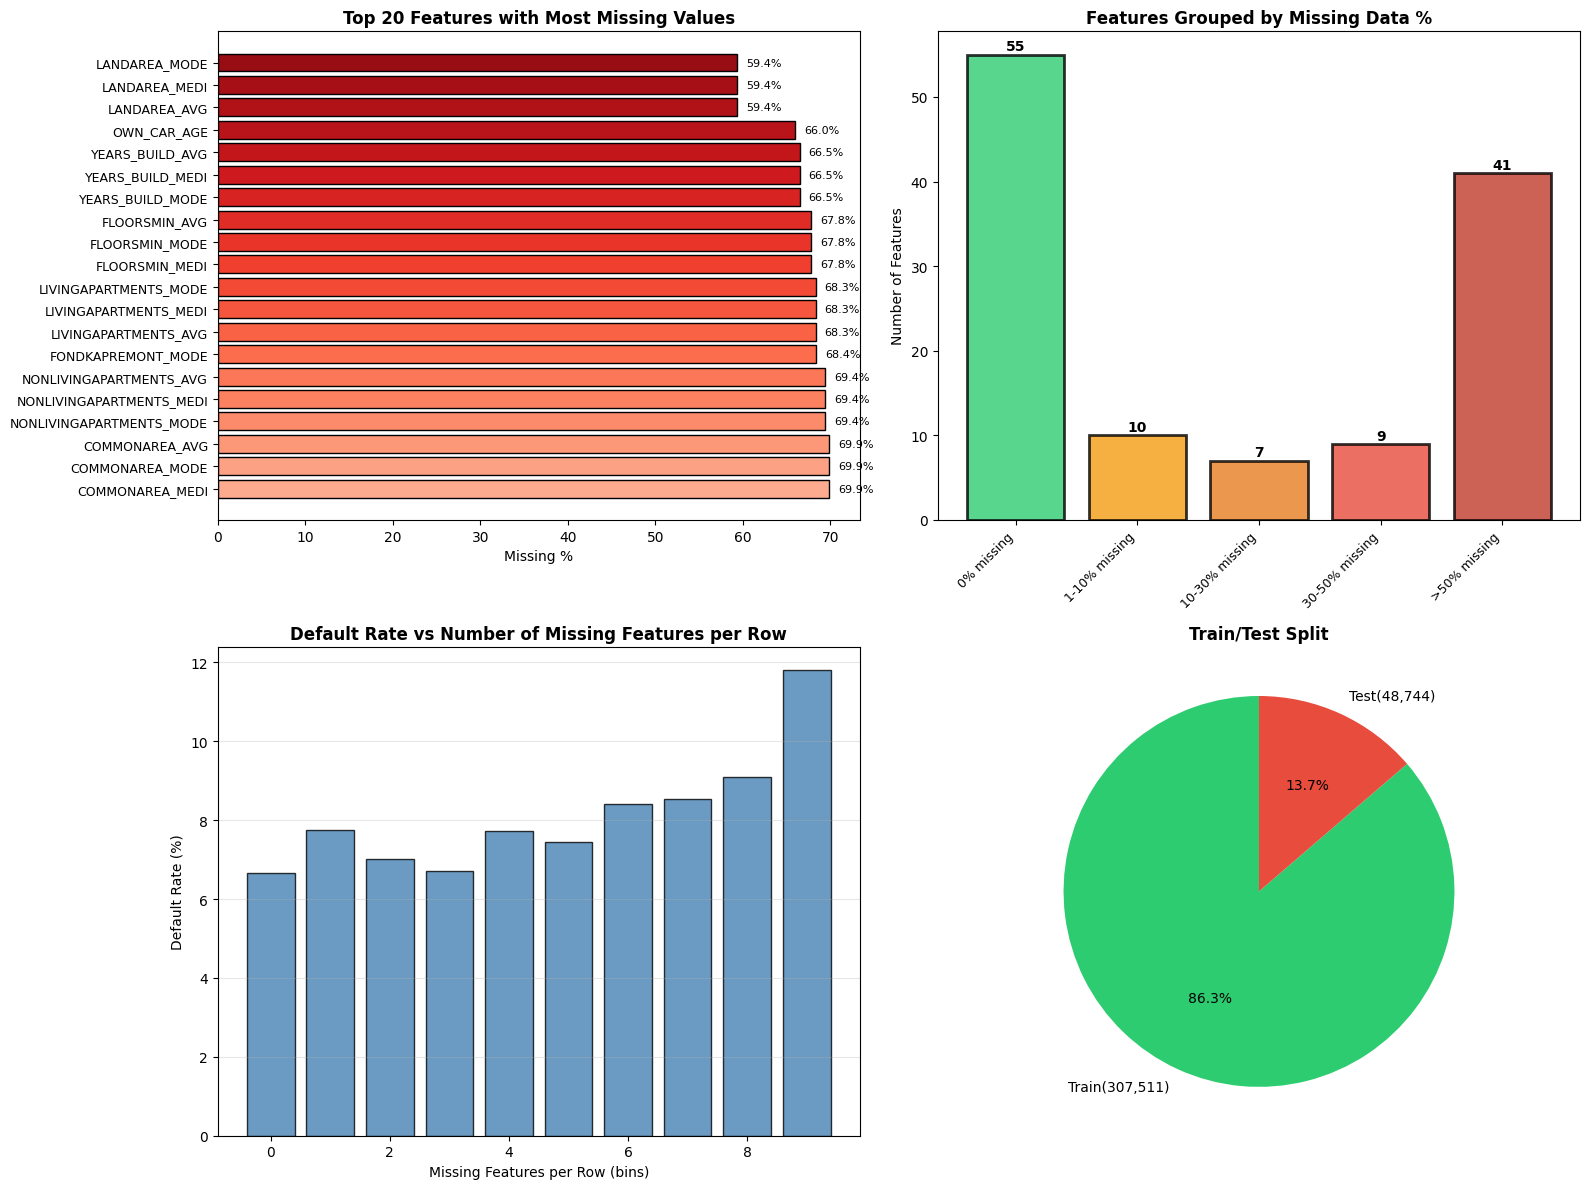

MISSING VALUES SUMMARY:
Total missing cells: 9,152,465 / 37,516,342 (24.40%)
Rows with ANY missing: 298,909 / 307,511
Features with >50% missing: 41


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top 20 features with most missing values
missing_sorted = missing_stats.sort_values('missing_%', ascending=False).head(20)
axes[0, 0].barh(range(len(missing_sorted)), missing_sorted['missing_%'].values, 
               color=plt.cm.Reds(np.linspace(0.3, 0.9, len(missing_sorted))), edgecolor='black')
axes[0, 0].set_yticks(range(len(missing_sorted)))
axes[0, 0].set_yticklabels(missing_sorted.index, fontsize=9)
axes[0, 0].set_xlabel('Missing %')
axes[0, 0].set_title('Top 20 Features with Most Missing Values', fontsize=12, fontweight='bold')
for i, v in enumerate(missing_sorted['missing_%'].values):
    axes[0, 0].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=8)

# Distribution of missing values across dataset
total_missing = df_train.isna().sum().sum()
total_cells = df_train.shape[0] * df_train.shape[1]
missing_by_category = {
    '0% missing': len([c for c in df_train.columns if df_train[c].isna().sum() == 0]),
    '1-10% missing': len([c for c in df_train.columns if 0 < df_train[c].isna().mean() <= 0.1]),
    '10-30% missing': len([c for c in df_train.columns if 0.1 < df_train[c].isna().mean() <= 0.3]),
    '30-50% missing': len([c for c in df_train.columns if 0.3 < df_train[c].isna().mean() <= 0.5]),
    '>50% missing': len([c for c in df_train.columns if df_train[c].isna().mean() > 0.5])
}

axes[0, 1].bar(range(len(missing_by_category)), list(missing_by_category.values()), 
              color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b'], 
              alpha=0.8, edgecolor='black', linewidth=2)
axes[0, 1].set_xticks(range(len(missing_by_category)))
axes[0, 1].set_xticklabels(missing_by_category.keys(), rotation=45, ha='right', fontsize=9)
axes[0, 1].set_ylabel('Number of Features')
axes[0, 1].set_title('Features Grouped by Missing Data %', fontsize=12, fontweight='bold')
for i, v in enumerate(missing_by_category.values()):
    axes[0, 1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Default rate vs Missing values per row
df_train_missing = df_train.copy()
df_train_missing['MISSING_COUNT'] = df_train_missing.isna().sum(axis=1)
miss_bins = pd.cut(df_train_missing['MISSING_COUNT'], bins=10)
default_by_missing = df_train_missing.groupby(miss_bins)['TARGET'].agg(['mean', 'count'])

axes[1, 0].bar(range(len(default_by_missing)), default_by_missing['mean'].values * 100, 
              alpha=0.8, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Missing Features per Row (bins)')
axes[1, 0].set_ylabel('Default Rate (%)')
axes[1, 0].set_title('Default Rate vs Number of Missing Features per Row', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

#4
sizes = [len(df_train), len(df_test)]
labels = [f'Train({len(df_train):,})', f'Test({len(df_test):,})']
colors = ['#2ecc71', '#e74c3c']
axes[1, 1].pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1, 1].set_title('Train/Test Split', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'MISSING VALUES SUMMARY:')
print(f'Total missing cells: {total_missing:,} / {total_cells:,} ({total_missing/total_cells*100:.2f}%)')
print(f'Rows with ANY missing: {(df_train_missing["MISSING_COUNT"] > 0).sum():,} / {len(df_train):,}')
print(f'Features with >50% missing: {missing_by_category[">50% missing"]}')

# TARGET-ORIENTED ANALYSIS

In [7]:
target_dist = df_train['TARGET'].value_counts()
print(f"Default: {target_dist.get(1, 0):,} ({target_dist.get(1, 0)/len(df_train)*100:.2f}%)")
print(f"Non-default: {target_dist.get(0, 0):,} ({target_dist.get(0, 0)/len(df_train)*100:.2f}%)")

Default: 24,825 (8.07%)
Non-default: 282,686 (91.93%)


DEFAULT RATE BY AGE:
           default_rate  count
AGE                           
(0, 25]        0.122946  12233
(25, 35]       0.106601  72429
(35, 45]       0.084084  84261
(45, 55]       0.070466  70190
(55, 65]       0.054212  60522
(65, 100]      0.036567   7876


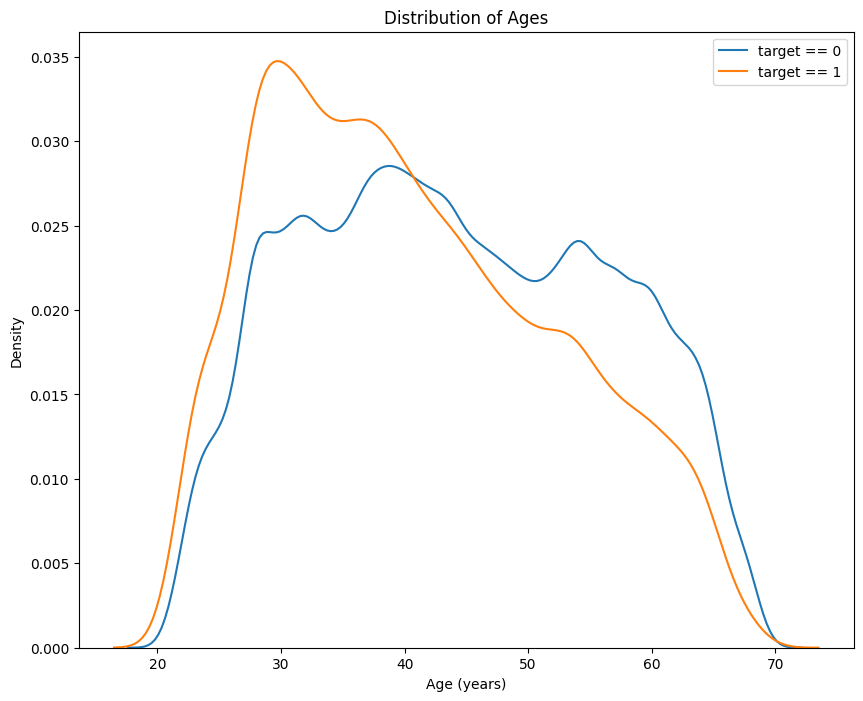

In [8]:
# Age analysis and distibution
if 'DAYS_BIRTH' in df_train.columns:
    df_train['AGE'] = -df_train['DAYS_BIRTH'] / 365.25
    age_bins = pd.cut(df_train['AGE'], bins=[0, 25, 35, 45, 55, 65, 100])
    age_default = df_train.groupby(age_bins)['TARGET'].agg(['mean', 'count'])
    age_default.columns = ['default_rate', 'count']
    print('DEFAULT RATE BY AGE:')
    print(age_default)

plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(df_train.loc[df_train['TARGET'] == 0, 'DAYS_BIRTH'] / -365, label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(df_train.loc[df_train['TARGET'] == 1, 'DAYS_BIRTH'] / -365, label = 'target == 1')
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages');plt.legend();

In [35]:
# Income analysis
if 'AMT_INCOME_TOTAL' in df_train.columns:
    income_bins = pd.qcut(df_train['AMT_INCOME_TOTAL'], q=5, duplicates='drop')
    income_default = df_train.groupby(income_bins)['TARGET'].agg(['mean', 'count'])
    income_default.columns = ['default_rate', 'count']
    print('DEFAULT RATE BY INCOME QUINTILE:')
    print(income_default)

DEFAULT RATE BY INCOME QUINTILE:
                         default_rate  count
AMT_INCOME_TOTAL                            
(25649.999, 99000.0]         0.082062  63671
(99000.0, 135000.0]          0.085883  85756
(135000.0, 162000.0]         0.086847  35453
(162000.0, 225000.0]         0.080569  75513
(225000.0, 117000000.0]      0.065198  47118


# DATA QUALITY ANALYSIS

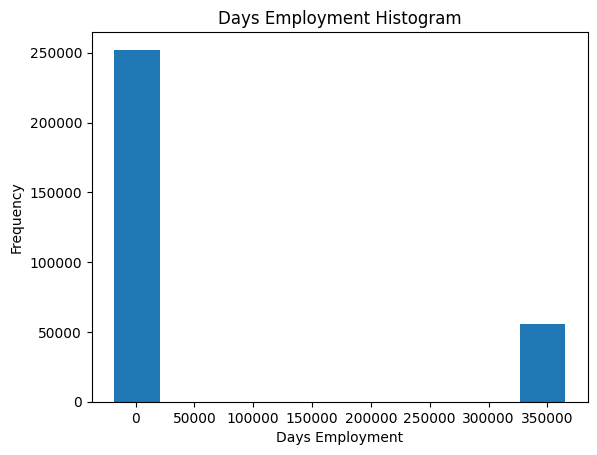

In [10]:
app_train = df_train
app_test = df_test
app_train['DAYS_EMPLOYED'].describe()
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

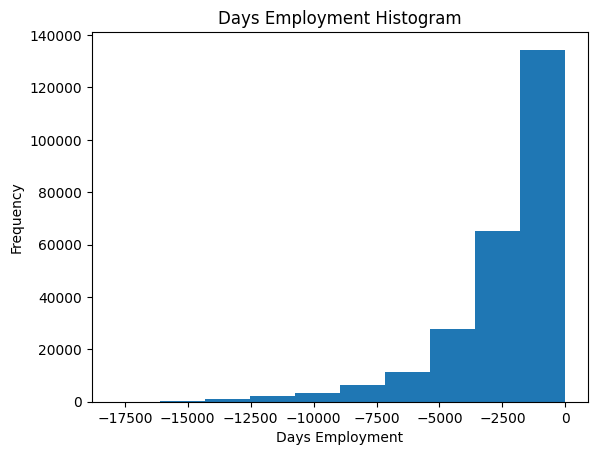

In [37]:
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram');
plt.xlabel('Days Employment');

In [12]:
# Default rate by numeric features
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.drop('TARGET')
print('DEFAULT RATE BY NUMERIC FEATURES (sample):')

for col in numeric_cols[:5]:
    try:
        binned = pd.qcut(df_train[col].fillna(df_train[col].median()), q=5, duplicates='drop')
        default_rate = df_train.groupby(binned)['TARGET'].mean()
        avg_rate = default_rate.mean()
        print(f"{col:30s}: avg default rate = {avg_rate:.3f}")
    except:
        pass

DEFAULT RATE BY NUMERIC FEATURES (sample):
SK_ID_CURR                    : avg default rate = 0.081
CNT_CHILDREN                  : avg default rate = 0.084
AMT_INCOME_TOTAL              : avg default rate = 0.080
AMT_CREDIT                    : avg default rate = 0.081
AMT_ANNUITY                   : avg default rate = 0.081


This is a statistical approach to find extreme values:

In [13]:
print('OUTLIERS:')
outlier_counts = {}
for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_train[col] < lower) | (df_train[col] > upper)).sum()
    if outliers > 0:
        outlier_counts[col] = outliers

for col, count in sorted(outlier_counts.items(), key=lambda x: x[1], reverse=True)[:10]:
    pct = count / len(df_train) * 100
    print(f"{col:30s}: {count:6d} ({pct:5.2f}%)")

OUTLIERS:
REGION_RATING_CLIENT          :  80527 (26.19%)
REGION_RATING_CLIENT_W_CITY   :  78027 (25.37%)
REG_CITY_NOT_WORK_CITY        :  70867 (23.05%)
FLAG_WORK_PHONE               :  61308 (19.94%)
FLAG_EMP_PHONE                :  55386 (18.01%)
LIVE_CITY_NOT_WORK_CITY       :  55215 (17.96%)
AMT_REQ_CREDIT_BUREAU_QRT     :  50575 (16.45%)
AMT_REQ_CREDIT_BUREAU_MON     :  43759 (14.23%)
DEF_30_CNT_SOCIAL_CIRCLE      :  35166 (11.44%)
FLAG_DOCUMENT_6               :  27078 ( 8.81%)


In [14]:
# Special/impossible values
cat_cols = df_train.select_dtypes(include=['object']).columns #This line gets all categorical columns (columns with text values like 'M', 'F', 'APPROVED', etc.).
for col in cat_cols:
    xna_count = (df_train[col] == 'XNA').sum() 
    if xna_count > 0:
        print(f"{col:30s}: {xna_count:6d} XNA values")

# Check for special codes in DAYS columns
for col in df_train.columns:
    if 'DAYS' in col and df_train[col].dtype in [np.int64, np.float64]:
        special = df_train[df_train[col].isin([365243, -999999])]
        if len(special) > 0:
            print(f"{col:30s}: {len(special):6d} special code values")

CODE_GENDER                   :      4 XNA values
ORGANIZATION_TYPE             :  55374 XNA values


Total numeric features: 106


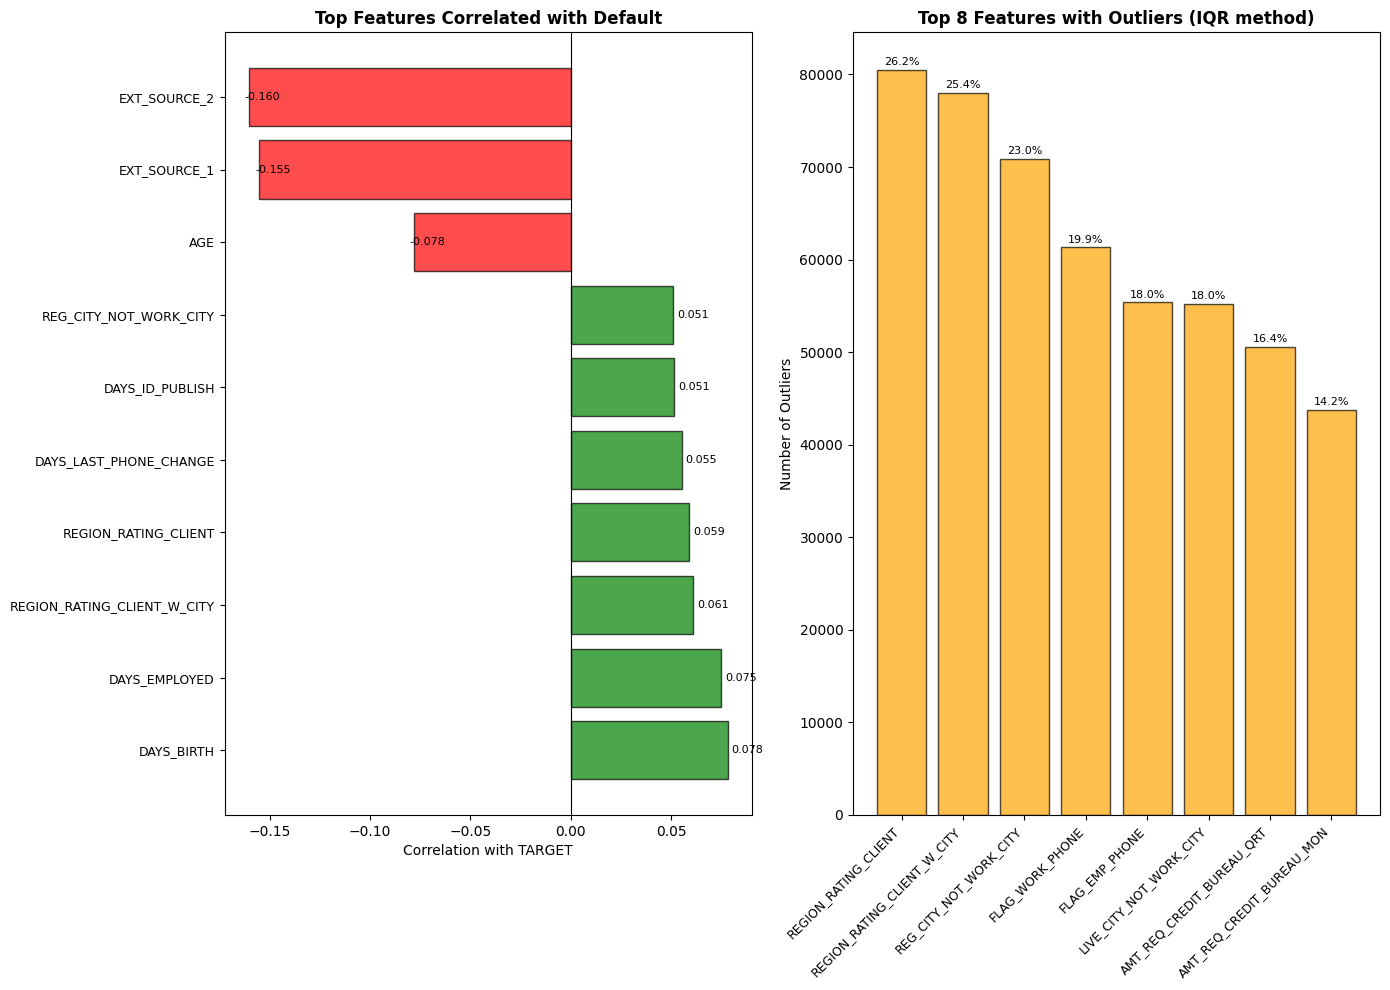

In [15]:
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.drop('TARGET')
print(f"Total numeric features: {len(numeric_cols)}")

# Top correlated features
correlations = df_train[numeric_cols].corrwith(df_train['TARGET']).sort_values(ascending=False)
top_corr = correlations[abs(correlations) > 0.05].head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# 1. Top correlations
colors_corr = ['green' if x > 0 else 'red' for x in top_corr.values]
axes[0].barh(range(len(top_corr)), top_corr.values, color=colors_corr, alpha=0.7, edgecolor='black')
axes[0].set_yticks(range(len(top_corr)))
axes[0].set_yticklabels(top_corr.index, fontsize=9)
axes[0].set_xlabel('Correlation with TARGET')
axes[0].set_title('Top Features Correlated with Default', fontsize=12, fontweight='bold')
axes[0].axvline(0, color='black', linestyle='-', linewidth=0.8)
for i, v in enumerate(top_corr.values):
    axes[0].text(v + 0.002 if v > 0 else v - 0.002, i, f'{v:.3f}', va='center', fontsize=8)

# 2. Outliers summary
outlier_summary = {}
for col in numeric_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_train[col] < lower) | (df_train[col] > upper)).sum()
    if outliers > 0:
        outlier_summary[col] = outliers

top_outliers = dict(sorted(outlier_summary.items(), key=lambda x: x[1], reverse=True)[:8])
axes[1].bar(range(len(top_outliers)), list(top_outliers.values()), alpha=0.7, color='orange', edgecolor='black')
axes[1].set_xticks(range(len(top_outliers)))
axes[1].set_xticklabels(top_outliers.keys(), rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Number of Outliers')
axes[1].set_title('Top 8 Features with Outliers (IQR method)', fontsize=12, fontweight='bold')
for i, v in enumerate(top_outliers.values()):
    pct = v / len(df_train) * 100
    axes[1].text(i, v + 500, f'{pct:.1f}%', ha='center', fontsize=8)


plt.tight_layout()
plt.show()

In [16]:
# Checking if there are constant columns with zero variance - there isn`t one
# constant_cols = [col for col in numeric_cols if df_train[col].nunique() <= 1]
# if constant_cols:
#     print(constant_cols)
# else:
#     print("No constant columns found.")

Total categorical features: 16


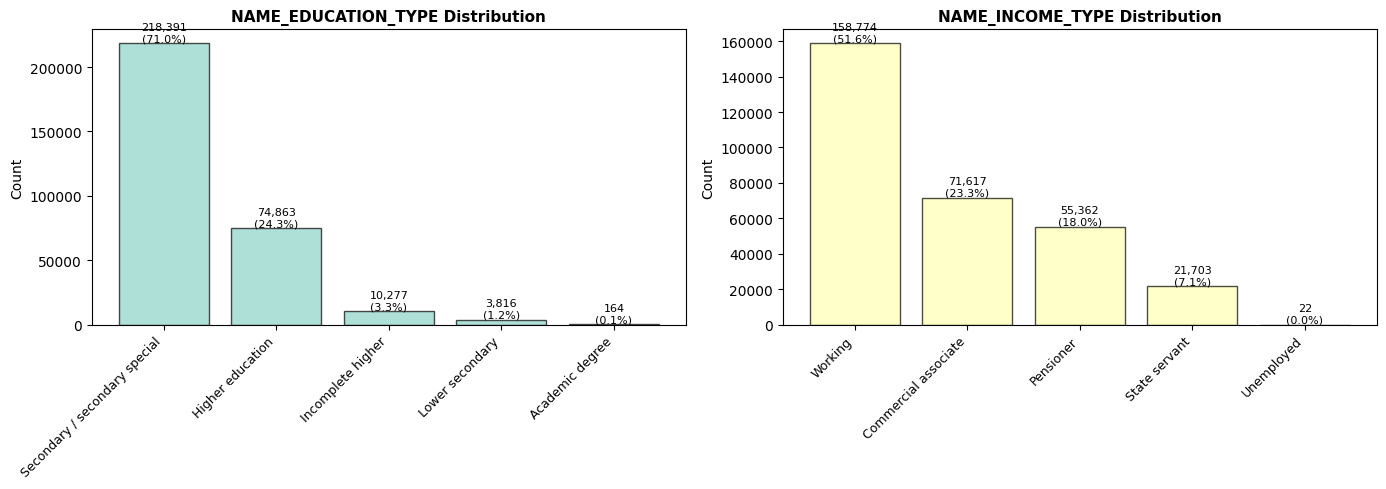

In [17]:
cat_cols = df_train.select_dtypes(include=['object']).columns
print(f"Total categorical features: {len(cat_cols)}")

# Sample important categorical features
important_cat = ['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE']
important_cat = [c for c in important_cat if c in df_train.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, col in enumerate(important_cat[2:4]):
    value_counts = df_train[col].value_counts().head(5)
    ax = axes[idx]
    
    bars = ax.bar(range(len(value_counts)), value_counts.values, alpha=0.7, edgecolor='black', color=plt.cm.Set3(idx))
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Count')
    ax.set_title(f'{col} Distribution', fontsize=11, fontweight='bold')
    
    # Add counts on bars
    for i, (bar, val) in enumerate(zip(bars, value_counts.values)):
        pct = val / len(df_train) * 100
        ax.text(i, val, f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# FEATURE RELATIONSHIP ANALYSIS

In [18]:
# Correlation with target - in case of a feature being with high correlation, so we can abuse it
print('TOP FEATURES CORRELATED WITH DEFAULT:')
target_corr = df_train[numeric_cols].corrwith(df_train['TARGET']).sort_values(ascending=False)
print(target_corr[abs(target_corr) > 0.05].head(15))

TOP FEATURES CORRELATED WITH DEFAULT:
DAYS_BIRTH                     0.078239
DAYS_EMPLOYED                  0.074958
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
AGE                           -0.078239
EXT_SOURCE_1                  -0.155317
EXT_SOURCE_2                  -0.160472
EXT_SOURCE_3                  -0.178919
dtype: float64


In [19]:
# Feature interactions not only with 'TARGET' but with each other, so we can try to abuse it too
if 'AMT_CREDIT' in df_train.columns and 'AMT_INCOME_TOTAL' in df_train.columns:
    df_train['INTERACTION_CREDIT_INCOME'] = df_train['AMT_CREDIT'] * df_train['AMT_INCOME_TOTAL']
    interaction_corr = df_train['INTERACTION_CREDIT_INCOME'].corr(df_train['TARGET'])
    print(f'Credit x Income interaction correlation: {interaction_corr:.4f}')

if 'DAYS_EMPLOYED' in df_train.columns and 'AGE' in df_train.columns:
    df_train['INTERACTION_AGE_EMPLOYED'] = df_train['AGE'] * df_train['DAYS_EMPLOYED']
    interaction_corr2 = df_train['INTERACTION_AGE_EMPLOYED'].corr(df_train['TARGET'])
    print(f'Age x Employment interaction correlation: {interaction_corr2:.4f}')

Credit x Income interaction correlation: -0.0213
Age x Employment interaction correlation: 0.0747


In [20]:
# # Top feature heatmap - what correlate with what
# top_features = target_corr.abs().nlargest(10).index.tolist() + ['TARGET']
# fig, ax = plt.subplots(figsize=(10, 8))
# corr_matrix = df_train[top_features].corr()
# sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar_kws={'label': 'Correlation'})
# ax.set_title('Top Feature Correlations')
# plt.tight_layout()
# # The visualisation is created fully by AI to show the information in comprehencible for view way


# Later will be upgraded - so for now - not necessary

In [21]:
numeric_cols_list = df_train.select_dtypes(include=[np.number]).columns.drop('TARGET')
correlation_matrix = df_train[numeric_cols_list].corr()

# Find highly correlated pairs (r > 0.95)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

print(f'HIGHLY CORRELATED FEATURE PAIRS (r > 0.95):')
print(f'Found {len(high_corr_pairs)} redundant pairs:')
for feat1, feat2, corr in high_corr_pairs[:10]:
    print(f'{feat1:30s} ↔ {feat2:30s}: {corr:.4f}')
if len(high_corr_pairs) > 10:
    print(f'... and {len(high_corr_pairs) - 10} more pairs')

HIGHLY CORRELATED FEATURE PAIRS (r > 0.95):
Found 47 redundant pairs:
AMT_CREDIT                     ↔ AMT_GOODS_PRICE               : 0.9870
DAYS_BIRTH                     ↔ AGE                           : -1.0000
DAYS_EMPLOYED                  ↔ INTERACTION_AGE_EMPLOYED      : 0.9737
REGION_RATING_CLIENT           ↔ REGION_RATING_CLIENT_W_CITY   : 0.9508
APARTMENTS_AVG                 ↔ APARTMENTS_MODE               : 0.9733
APARTMENTS_AVG                 ↔ APARTMENTS_MEDI               : 0.9951
BASEMENTAREA_AVG               ↔ BASEMENTAREA_MODE             : 0.9735
BASEMENTAREA_AVG               ↔ BASEMENTAREA_MEDI             : 0.9943
YEARS_BEGINEXPLUATATION_AVG    ↔ YEARS_BEGINEXPLUATATION_MODE  : 0.9719
YEARS_BEGINEXPLUATATION_AVG    ↔ YEARS_BEGINEXPLUATATION_MEDI  : 0.9938
... and 37 more pairs


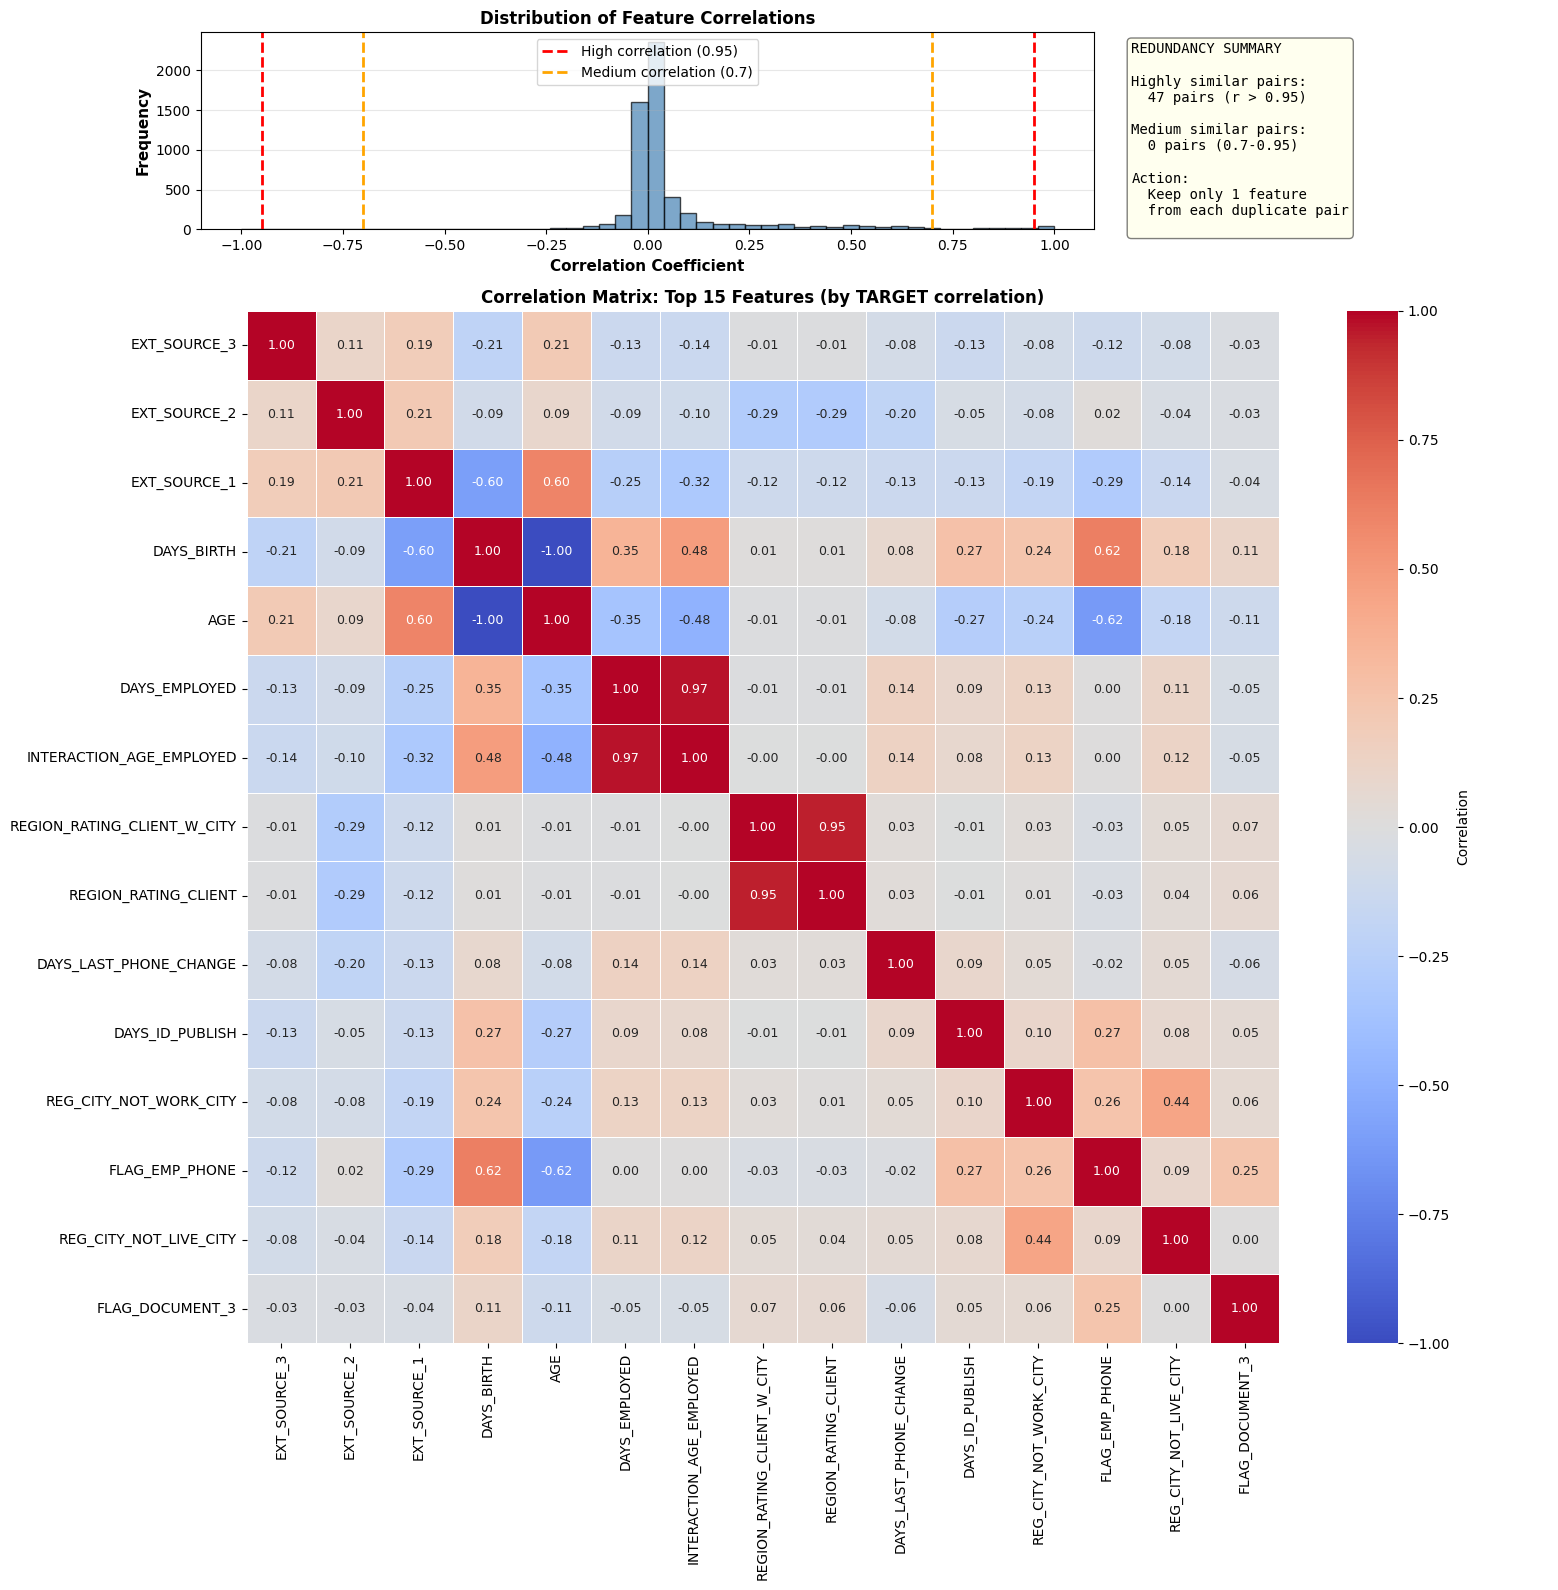

FEATURE REDUNDANCY SUMMARY:
Highly similar features (r > 0.95): 47 pairs
->These are essentially duplicates, keep only 1 from each pair
Top 5 redundant pairs to remove:
AMT_CREDIT                     <-> AMT_GOODS_PRICE               : r=0.9870
DAYS_BIRTH                     <-> AGE                           : r=-1.0000
DAYS_EMPLOYED                  <-> INTERACTION_AGE_EMPLOYED      : r=0.9737
REGION_RATING_CLIENT           <-> REGION_RATING_CLIENT_W_CITY   : r=0.9508
APARTMENTS_AVG                 <-> APARTMENTS_MODE               : r=0.9733


In [22]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 16))
gs = gridspec.GridSpec(5, 6, figure=fig)

# 1. Histogram (top, spans 2 columns)
ax1 = fig.add_subplot(gs[0, 0:4])
corr_values = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)]
ax1.hist(corr_values, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax1.axvline(0.95, color='red', linestyle='--', linewidth=2, label='High correlation (0.95)')
ax1.axvline(0.7, color='orange', linestyle='--', linewidth=2, label='Medium correlation (0.7)')
ax1.axvline(-0.95, color='red', linestyle='--', linewidth=2)
ax1.axvline(-0.7, color='orange', linestyle='--', linewidth=2)
ax1.set_xlabel('Correlation Coefficient', fontsize=11, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Feature Correlations', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Summary text (top-right)
ax_summary = fig.add_subplot(gs[0, 4:6])
summary_text = f"""REDUNDANCY SUMMARY

Highly similar pairs:
  {len(high_corr_pairs)} pairs (r > 0.95)
  
Medium similar pairs:
  {len([p for p in high_corr_pairs if abs(p[2]) < 0.95 and abs(p[2]) > 0.7])} pairs (0.7-0.95)
  
Action:
  Keep only 1 feature
  from each duplicate pair
"""
ax_summary.text(0.05, 0.95, summary_text, transform=ax_summary.transAxes, 
               fontsize=10, verticalalignment='top', family='monospace',
               bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))
ax_summary.axis('off')

# 3. Large heatmap (bottom, spans 3 columns)
ax2 = fig.add_subplot(gs[1:5, :])
feature_corr_with_target = df_train[numeric_cols_list].corrwith(df_train['TARGET']).abs().sort_values(ascending=False)
top_features = feature_corr_with_target.head(15).index.tolist()  # Increased to 15 for better view

top_corr_matrix = df_train[top_features].corr()
sns.heatmap(top_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
           ax=ax2, cbar_kws={'label': 'Correlation'}, 
           square=True, linewidths=0.7, annot_kws={'fontsize': 9})
ax2.set_title('Correlation Matrix: Top 15 Features (by TARGET correlation)', 
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'FEATURE REDUNDANCY SUMMARY:')
print(f'Highly similar features (r > 0.95): {len(high_corr_pairs)} pairs')
print(f'->These are essentially duplicates, keep only 1 from each pair')
print(f'Top 5 redundant pairs to remove:')
for feat1, feat2, corr in high_corr_pairs[:5]:
    print(f'{feat1:30s} <-> {feat2:30s}: r={corr:.4f}')

# MULTI-TABLE ANALYSIS (Previous Credit History)

In [23]:
# Load supplementary tables from competition files to also investigate them at least for a little
bureau_available = False
prev_app_available = False
bureau_balance_available = False

try:
    bureau = pd.read_csv(DATA_PATH / 'bureau.csv')
    bureau_available = True
    print(f"Bureau data loaded: {bureau.shape}")
    prev_app = pd.read_csv(DATA_PATH / 'previous_application.csv')
    prev_app_available = True
    print(f"Previous applications loaded: {prev_app.shape}")
    bureau_balance = pd.read_csv(DATA_PATH / 'bureau_balance.csv')
    bureau_balance_available = True
    print(f"Bureau balance data loaded: {bureau_balance.shape}")
except:
    print("Some of these are unavailable")

Bureau data loaded: (1716428, 17)
Previous applications loaded: (1670214, 37)
Bureau balance data loaded: (27299925, 3)


In [24]:
if bureau_available:
    # Previous credit count
    prev_credit = bureau.groupby('SK_ID_CURR').size().rename('PREV_CREDIT_COUNT')
    df_train = df_train.merge(prev_credit, left_on='SK_ID_CURR', right_index=True, how='left')
    df_train['PREV_CREDIT_COUNT'] = df_train['PREV_CREDIT_COUNT'].fillna(0)
    corr_prev = df_train['PREV_CREDIT_COUNT'].corr(df_train['TARGET'])
    print(f'Previous credit count -> default correlation: {corr_prev:.4f}')
    # Credit balance status
    status_dist = bureau['CREDIT_ACTIVE'].value_counts()
    print(f'Previous credit status distribution: {status_dist}')

Previous credit count -> default correlation: -0.0100
Previous credit status distribution: CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64


In [25]:
if prev_app_available:
    # Previous approved applications
    approved = (prev_app['NAME_CONTRACT_STATUS'] == 'Approved').groupby(prev_app['SK_ID_CURR']).sum().rename('PREV_APPROVED')
    df_train = df_train.merge(approved, left_on='SK_ID_CURR', right_index=True, how='left')
    df_train['PREV_APPROVED'] = df_train['PREV_APPROVED'].fillna(0)
    corr_approved = df_train['PREV_APPROVED'].corr(df_train['TARGET'])
    print(f'Previous approved applications -> default correlation: {corr_approved:.4f}')
    # Previous application outcomes
    outcome_dist = prev_app['NAME_CONTRACT_STATUS'].value_counts()
    print(f'Previous application outcomes: {outcome_dist}')

Previous approved applications -> default correlation: -0.0235
Previous application outcomes: NAME_CONTRACT_STATUS
Approved        1036781
Canceled         316319
Refused          290678
Unused offer      26436
Name: count, dtype: int64


In [26]:
if bureau_available:
    # Delinquency history
    has_delinq = (bureau['CREDIT_DAY_OVERDUE'] > 0).groupby(bureau['SK_ID_CURR']).any().astype(int).rename('HAS_DELINQUENCY')
    df_train = df_train.merge(has_delinq, left_on='SK_ID_CURR', right_index=True, how='left')
    df_train['HAS_DELINQUENCY'] = df_train['HAS_DELINQUENCY'].fillna(0)
    corr_delinq = df_train['HAS_DELINQUENCY'].corr(df_train['TARGET'])
    print(f'Has delinquency history -> default correlation: {corr_delinq:.4f}')
    delinq_default = df_train.groupby('HAS_DELINQUENCY')['TARGET'].mean()
    print(f'Default rate by delinquency history: {delinq_default}')

Has delinquency history -> default correlation: 0.0304
Default rate by delinquency history: HAS_DELINQUENCY
0.0    0.079855
1.0    0.158964
Name: TARGET, dtype: float64


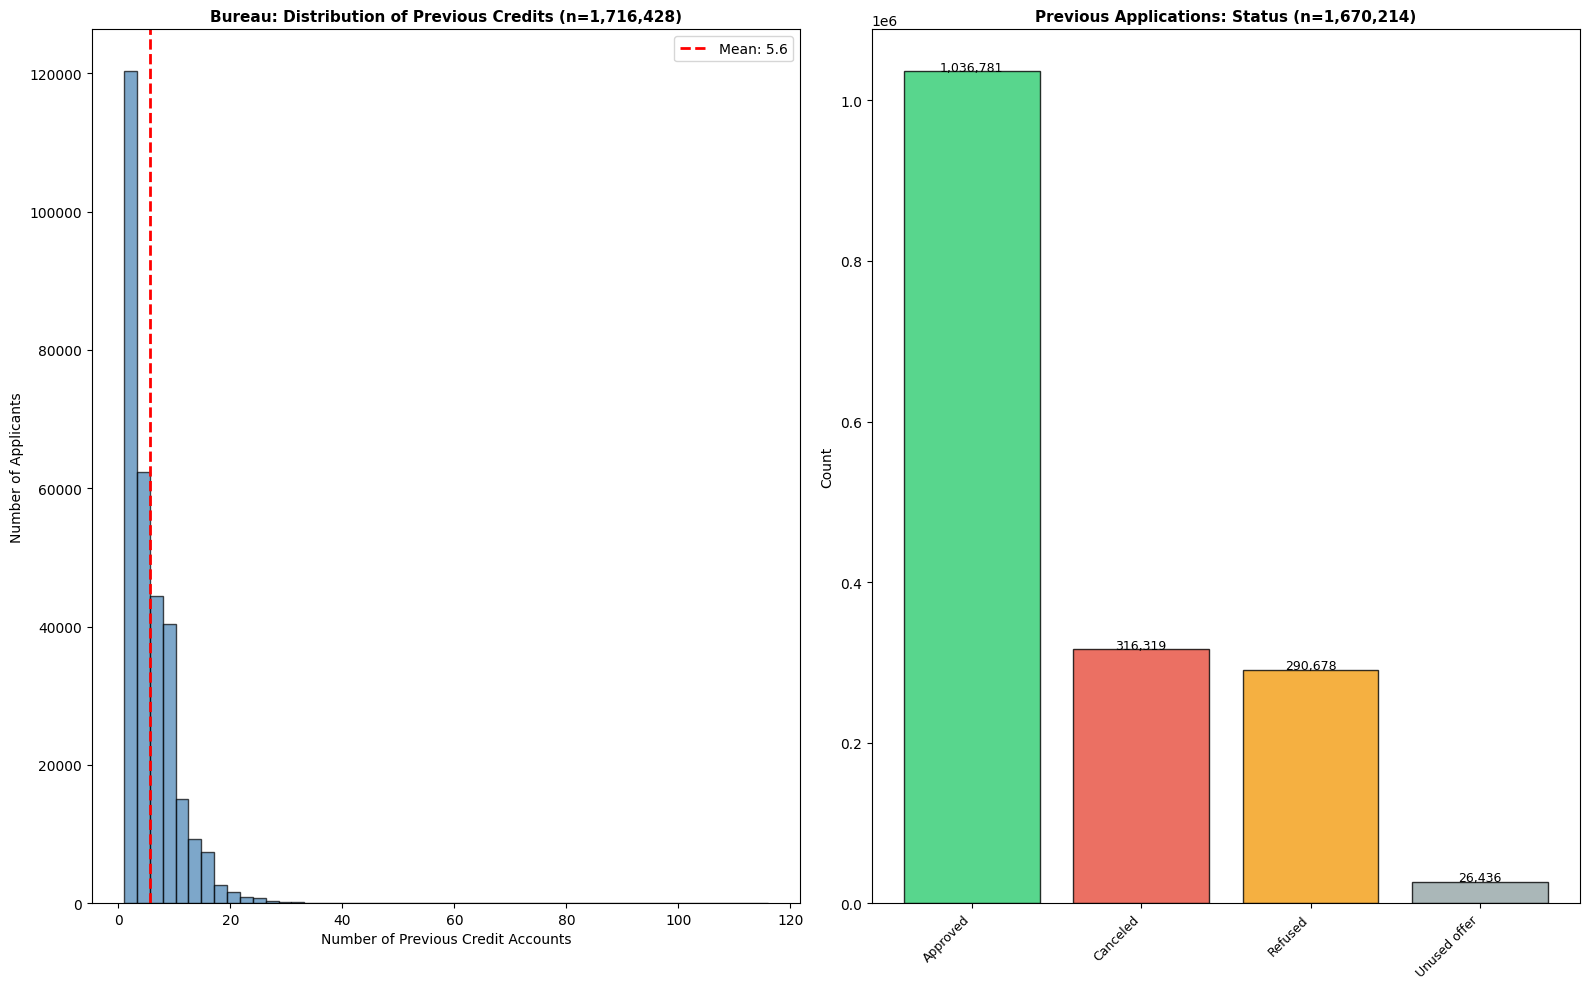

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# 1. Bureau - Previous credit accounts
if bureau_available:
    prev_credit_count = bureau.groupby('SK_ID_CURR').size()
    axes[0].hist(prev_credit_count, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Number of Previous Credit Accounts')
    axes[0].set_ylabel('Number of Applicants')
    axes[0].set_title(f'Bureau: Distribution of Previous Credits (n={len(bureau):,})', 
                       fontsize=11, fontweight='bold')
    axes[0].axvline(prev_credit_count.mean(), color='red', linestyle='--', 
                      linewidth=2, label=f'Mean: {prev_credit_count.mean():.1f}')
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'Bureau data not available', ha='center', va='center',
                   transform=axes[0].transAxes, fontsize=11)

# 2. Previous Applications - Status distribution
if prev_app_available:
    status_counts = prev_app['NAME_CONTRACT_STATUS'].value_counts()
    axes[1].bar(range(len(status_counts)), status_counts.values, 
                  color=['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6'][:len(status_counts)],
                  alpha=0.8, edgecolor='black')
    axes[1].set_xticks(range(len(status_counts)))
    axes[1].set_xticklabels(status_counts.index, rotation=45, ha='right', fontsize=9)
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'Previous Applications: Status (n={len(prev_app):,})', 
                       fontsize=11, fontweight='bold')
    for i, v in enumerate(status_counts.values):
        axes[1].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'Previous Applications data not available', ha='center', 
                   va='center', transform=axes[0, 1].transAxes, fontsize=11)

plt.tight_layout()
plt.show()

# TRAIN/TEST DATA COMPARISON

In [28]:
print('SHAPE COMPARISON:')
print(f"Training set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print(f"Common columns: {len(set(df_train.columns) & set(df_test.columns))}")
print(f"Train-only columns: {set(df_train.columns) - set(df_test.columns)}")

SHAPE COMPARISON:
Training set: (307511, 129)
Test set: (48744, 121)
Common columns: 121
Train-only columns: {'DAYS_EMPLOYED_ANOM', 'PREV_CREDIT_COUNT', 'AGE', 'INTERACTION_CREDIT_INCOME', 'HAS_DELINQUENCY', 'INTERACTION_AGE_EMPLOYED', 'TARGET', 'PREV_APPROVED'}


In [29]:
# Distribution differences in case it can be a deal
common_cols = [c for c in numeric_cols if c in df_test.columns]
top_common = target_corr.abs().nlargest(5).index.tolist()
top_common = [c for c in top_common if c in df_test.columns]

comparison = pd.DataFrame({
    'train_mean': df_train[top_common].mean(),
    'test_mean': df_test[top_common].mean(),
    'diff_pct': ((df_test[top_common].mean() - df_train[top_common].mean()) / (df_train[top_common].mean().abs() + 1) * 100).round(2)
})
print(comparison)

                train_mean     test_mean  diff_pct
EXT_SOURCE_3      0.510853      0.500106     -0.71
EXT_SOURCE_2      0.514393      0.518021      0.24
EXT_SOURCE_1      0.502130      0.501180     -0.06
DAYS_BIRTH   -16036.995067 -16068.084605     -0.19


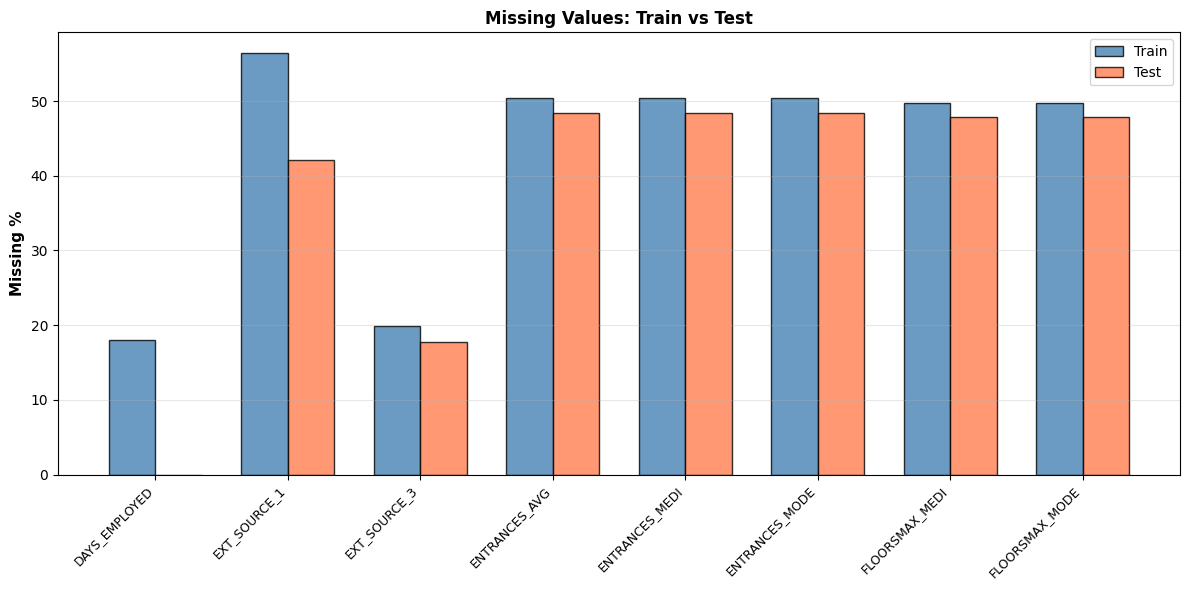

In [30]:
# 3. Missing value comparison
common_cols = [c for c in df_train.columns if c in df_test.columns]
missing_comparison = pd.DataFrame({
    'Train': (df_train[common_cols].isna().sum() / len(df_train) * 100),
    'Test': (df_test[common_cols].isna().sum() / len(df_test) * 100)
})
missing_comparison['Diff'] = abs(missing_comparison['Train'] - missing_comparison['Test'])
missing_comparison = missing_comparison[missing_comparison['Diff'] > 0].sort_values('Diff', ascending=False).head(8)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(missing_comparison))
width = 0.35
ax.bar(x - width/2, missing_comparison['Train'], width, label='Train', alpha=0.8, color='steelblue', edgecolor='black')
ax.bar(x + width/2, missing_comparison['Test'], width, label='Test', alpha=0.8, color='coral', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(missing_comparison.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Missing %', fontsize=11, fontweight='bold')
ax.set_title('Missing Values: Train vs Test', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [31]:
# Missingness comparison
common_cols_all = [c for c in df_train.columns if c in df_test.columns]
missing_comparison = pd.DataFrame({
    'train_missing_%': (df_train[common_cols_all].isna().mean() * 100).round(2),
    'test_missing_%': (df_test[common_cols_all].isna().mean() * 100).round(2)
})
missing_comparison = missing_comparison[(missing_comparison['train_missing_%'] > 0) | (missing_comparison['test_missing_%'] > 0)]
print(missing_comparison.sort_values('train_missing_%', ascending=False))

                          train_missing_%  test_missing_%
COMMONAREA_MODE                     69.87           68.72
COMMONAREA_AVG                      69.87           68.72
COMMONAREA_MEDI                     69.87           68.72
NONLIVINGAPARTMENTS_MEDI            69.43           68.41
NONLIVINGAPARTMENTS_MODE            69.43           68.41
...                                   ...             ...
DEF_30_CNT_SOCIAL_CIRCLE             0.33            0.06
DEF_60_CNT_SOCIAL_CIRCLE             0.33            0.06
EXT_SOURCE_2                         0.21            0.02
AMT_GOODS_PRICE                      0.09            0.00
AMT_ANNUITY                          0.00            0.05

[66 rows x 2 columns]


# EDA SUMMARY

In [32]:
print(f"Dataset Overview: {df_train.shape[0]:,} rows x {df_train.shape[1]} features")
print(f"Target Balance: {df_train['TARGET'].mean():.2%} defaulters (imbalanced)")
print(f"Missing Data: {df_train.isna().sum().sum():,} cells ({df_train.isna().sum().sum()/(df_train.shape[0]*df_train.shape[1])*100:.1f}%)")
print(f"Numeric Features: {len(numeric_cols)}")
print(f"Categorical Features: {len(cat_cols)}")
print(f"Supplementary Tables: Bureau={bureau_available}, PrevApp={prev_app_available}, BureauBalance={bureau_balance_available}")

Dataset Overview: 307,511 rows x 129 features
Target Balance: 8.07% defaulters (imbalanced)
Missing Data: 9,263,213 cells (23.4%)
Numeric Features: 106
Categorical Features: 16
Supplementary Tables: Bureau=True, PrevApp=True, BureauBalance=True
